# Análise exploratória dos datasets — ClearColors G04

Este notebook faz uma **análise exploratória** (EDA) dos dados que estão em `datasets/derivados/`.
O objetivo é responder, de forma simples, a cinco perguntas:

| Etapa | Pergunta |
|---|---|
| 1. Estrutura | Como são as tabelas? Tem dado faltando ou repetido? |
| 2. Rótulos | Quais vereditos existem e em que proporção? |
| 3. Tempo e tema | De quando são as checagens e sobre o que falam? |
| 4. Texto | Os textos estão íntegros? Têm tamanhos parecidos entre classes? |
| 5. Vazamento | Existe alguma "pista boba" que entrega o rótulo sem ler o conteúdo? |


> **Como rodar:** abra no VS Code ou no Jupyter e use *Run All*. Precisa de `pandas` e `matplotlib`
> (`pip install pandas matplotlib`).

## 0. Preparação
Importamos as bibliotecas, localizamos a pasta de dados e definimos um estilo para os gráficos.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Procura a pasta datasets/derivados subindo a partir de onde o notebook está
aqui = Path.cwd()
for pasta in [aqui, *aqui.parents]:
    if (pasta / "datasets" / "derivados").exists():
        DADOS = pasta / "datasets" / "derivados"
        break
else:
    raise FileNotFoundError("Não achei datasets/derivados. Abra o notebook dentro do repositório.")
print("Lendo dados de:", DADOS.relative_to(pasta))

# Estilo dos gráficos: marcas finas, grade discreta, cores em ordem fixa
AZUL, LARANJA, AQUA, AMARELO = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
TINTA, TINTA2, GRADE = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRADE, "axes.labelcolor": TINTA2, "text.color": TINTA,
    "xtick.color": TINTA2, "ytick.color": TINTA2, "axes.grid": True,
    "grid.color": GRADE, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "font.size": 10, "figure.dpi": 110,
})

def barras_h(ax, serie, cor=AZUL, titulo="", pct=False):
    """Barras horizontais com o valor escrito ao lado (maior em cima)."""
    s = serie.sort_values()
    ax.barh(s.index.astype(str), s.values, color=cor, height=0.6)
    ax.grid(axis="y", visible=False)
    ax.set_title(titulo)
    for i, v in enumerate(s.values):
        rot = f"{v:.0%}" if pct else f"{v:,.0f}".replace(",", ".")
        ax.text(v, i, " " + rot, va="center", color=TINTA2, fontsize=9)
    ax.margins(x=0.15)
    if pct:
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

Lendo dados de: datasets/derivados


### Carregando as bases
Cada arquivo tem uma forma de leitura (separador diferente, colunas extras). Resolvemos da seguinte forma:

In [ ]:
fc   = pd.read_csv(DADOS / "factcenter_subset_saude.csv", sep=";")                 # checagens PT-BR de saúde (corpus do RAG)
fcv  = pd.read_csv(DADOS / "factcenter_vereditos_normalizados.csv")                # vereditos do FactCenter já padronizados
ck   = pd.read_csv(DADOS / "factckbr_normalizado.csv")                             # FACTCK.BR
fr   = pd.read_csv(DADOS / "fakerecogna2_subset_saude_ciencia.csv", index_col=0)   # FakeRecogna 2.0 (banco de estímulos)
fh   = pd.read_csv(DADOS / "fakehealth_criterios_long.csv")                        # FakeHealth: 1 critério por linha (inglês)
ex   = pd.read_csv(DADOS / "exagero_pares_abstract_vs_release.csv")                # InSciOut: artigo x press release

bases = {"FactCenter (saúde)": fc, "FactCenter vereditos": fcv, "FACTCK.BR": ck,
         "FakeRecogna 2.0 (saúde)": fr, "FakeHealth critérios": fh, "InSciOut (exagero)": ex}
print("Bases carregadas:", ", ".join(bases))

Bases carregadas: FactCenter (saúde), FactCenter vereditos, FACTCK.BR, FakeRecogna 2.0 (saúde), FakeHealth critérios, InSciOut (exagero)


---
## Etapa 1 — Estrutura: como são as tabelas?

Para cada base olhamos: **quantas linhas e colunas**, **quanto falta** (células vazias) e **quantas linhas repetidas** existem.
Dado faltando não é necessariamente erro: às vezes o campo é opcional (ex.: nem toda checagem tem vídeo).

In [3]:
resumo = pd.DataFrame({
    "linhas":          {n: len(d) for n, d in bases.items()},
    "colunas":         {n: d.shape[1] for n, d in bases.items()},
    "% células vazias": {n: round(d.isna().mean().mean() * 100, 1) for n, d in bases.items()},
    "linhas repetidas": {n: int(d.duplicated().sum()) for n, d in bases.items()},
})
resumo

,linhas,colunas,% células vazias,linhas repetidas
FactCenter (saúde),4063,13,12.0,0
FactCenter vereditos,4063,11,9.6,0
FACTCK.BR,1313,10,0.3,0
FakeRecogna 2.0 (saúde),26436,8,16.0,18
FakeHealth critérios,22959,12,0.2,0
InSciOut (exagero),663,6,0.0,0


Vamos ver **quais colunas** têm mais vazios nas duas bases em português mais importantes:

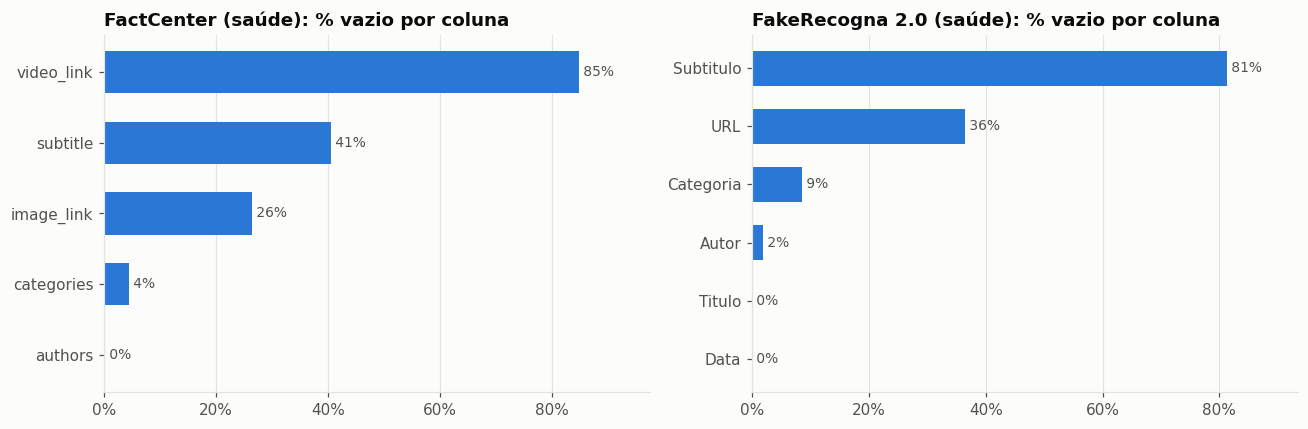

FactCenter  – URLs repetidas: 0 | textos repetidos: 0
FakeRecogna – notícias com texto repetido: 59


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (nome, d) in zip(axes, [("FactCenter (saúde)", fc), ("FakeRecogna 2.0 (saúde)", fr)]):
    vazios = d.isna().mean()
    barras_h(ax, vazios[vazios > 0], titulo=f"{nome}: % vazio por coluna", pct=True)
plt.tight_layout(); plt.show()

# Repetições que não aparecem como "linha inteira duplicada"
print("FactCenter  – URLs repetidas:", fc["url"].duplicated().sum(), "| textos repetidos:", fc["text_news"].duplicated().sum())
print("FakeRecogna – notícias com texto repetido:", fr["Noticia"].duplicated().sum())

**Observações:**
- No FactCenter, os vazios estão em campos opcionais (`video_link`, `subtitle`, `image_link`). O texto da checagem (`text_news`) está sempre presente. 
- No FakeRecogna faltam `URL` (≈37%) e `Subtitulo` (≈81%), e existem **notícias com texto repetido**. Para realizar uma futura amostra de estímulos, iremos realizar a remoção das duplicatas.

---
## Etapa 2 — Rótulos:

O rótulo é o veredito de cada item (falso, verdadeiro, etc.). Queremos saber:
1. se as classes estão **equilibradas**;
2. se o mesmo veredito aparece **escrito de jeitos diferentes** (o que exige padronizar).

In [ ]:
grafias = fc["rating"].str.strip("[]").str.split(",").explode().str.strip(" '\"")
print("Grafias distintas de veredito no FactCenter:", grafias.nunique())
print("Algumas formas de dizer 'falso':", sorted({g for g in grafias.unique() if "fals" in g.lower() or "fake" in g.lower()})[:10])

Grafias distintas de veredito no FactCenter: 26
Algumas formas de dizer 'falso': ['FALSO', 'Falso', 'fake', 'falso']


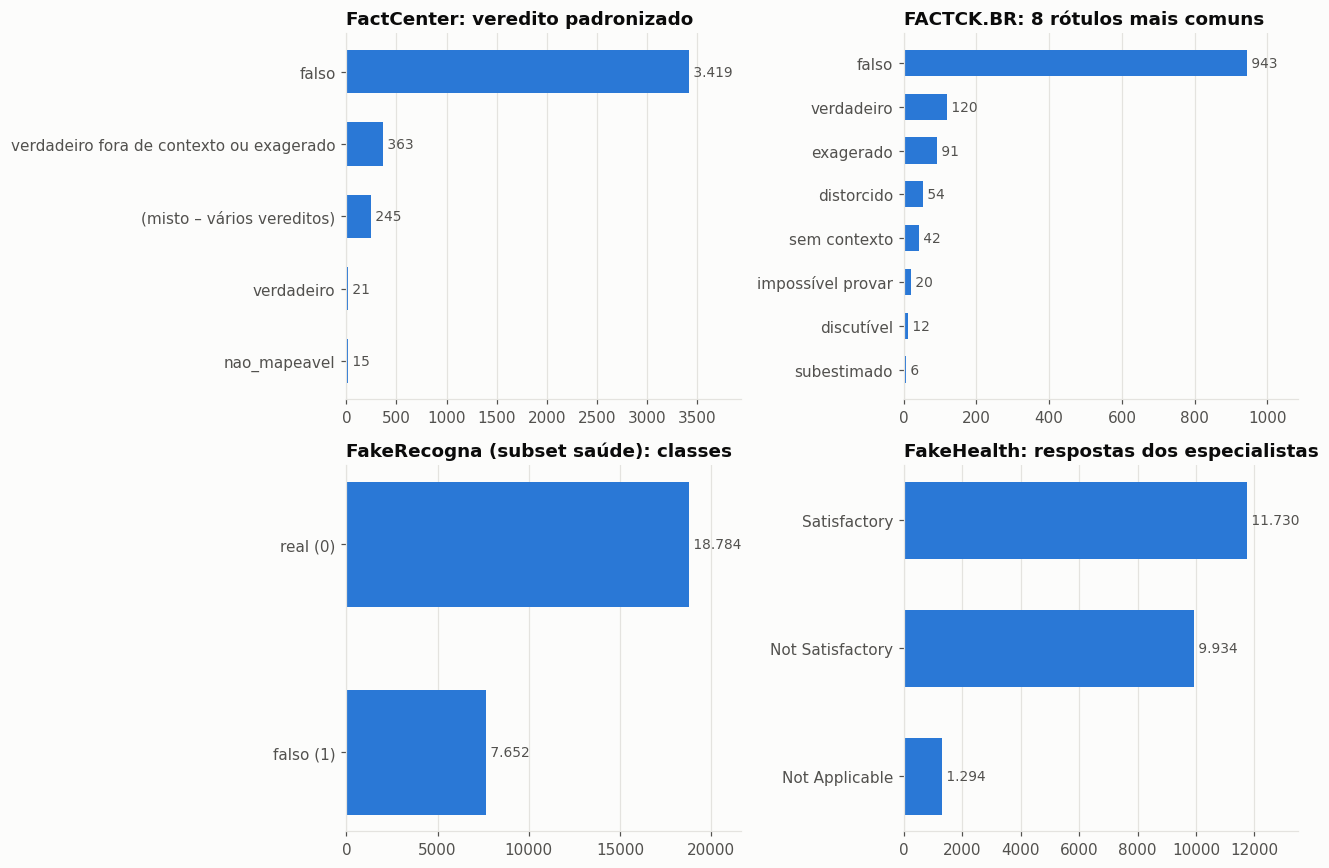

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

barras_h(axes[0, 0], fcv["rotulo_consolidado"].fillna("(misto – vários vereditos)").value_counts(),
         titulo="FactCenter: veredito padronizado")
barras_h(axes[0, 1], ck["rotulo_norm"].value_counts().head(8), titulo="FACTCK.BR: 8 rótulos mais comuns")
barras_h(axes[1, 0], fr["Label"].map({0: "real (0)", 1: "falso (1)"}).value_counts(),
         titulo="FakeRecogna (subset saúde): classes")
barras_h(axes[1, 1], fh["resposta"].value_counts(), titulo="FakeHealth: respostas dos especialistas")
plt.tight_layout(); plt.show()

E no InSciOut, cada par diz se o press release **mantém, exagera ou atenua** o que o artigo científico concluiu:

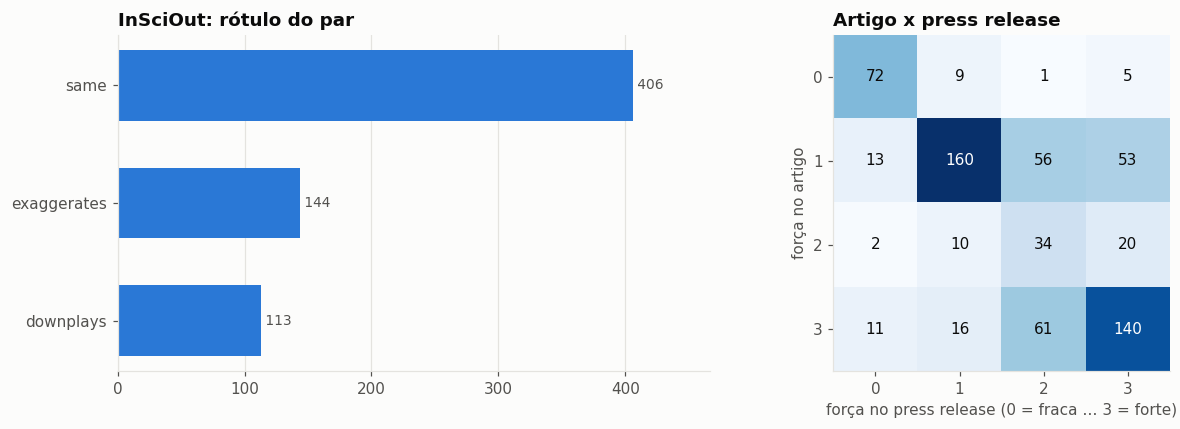

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
barras_h(axes[0], ex["exaggeration_label"].value_counts(), titulo="InSciOut: rótulo do par")

# Mapa de calor: força da afirmação no artigo (linhas) x no press release (colunas)
tab = pd.crosstab(ex["abstract_strength"], ex["press_release_strength"])
im = axes[1].imshow(tab.values, cmap="Blues")
axes[1].set_xticks(range(len(tab.columns)), tab.columns); axes[1].set_yticks(range(len(tab.index)), tab.index)
axes[1].set_xlabel("força no press release (0 = fraca … 3 = forte)"); axes[1].set_ylabel("força no artigo")
axes[1].grid(False); axes[1].set_title("Artigo x press release")
for i in range(tab.shape[0]):
    for j in range(tab.shape[1]):
        v = tab.values[i, j]
        axes[1].text(j, i, v, ha="center", va="center", color="white" if v > tab.values.max() / 2 else TINTA)
plt.tight_layout(); plt.show()

**Observações:**
- **Desequilíbrio extremo no FactCenter:** quase tudo é `falso` e só **21** itens são `verdadeiro`. Faz sentido (agência só checa o que é suspeito), mas significa que **não dá para tirar exemplos verdadeiros daqui**.
- O FactCenter usa **26 grafias** para poucos vereditos (`FALSO`, `Falso`, `fake`, `boato`...). Por isso existe a coluna `rotulo_consolidado`.
- No FakeHealth as respostas estão entre *Satisfactory* e *Not Satisfactory*, o que é bom para calibrar a Matriz de Confiança.
- No InSciOut, tudo que está **acima da diagonal** do mapa é exagero (o release afirma mais forte que o artigo). É um bom material para ensinar o critério "a manchete diz mais do que o estudo?".

---
## Etapa 3 — Tempo

Um verificador só ajuda se o corpus **cobre os assuntos que circulam hoje**. Aqui olhamos a distribuição por ano e contamos alguns termos de saúde.

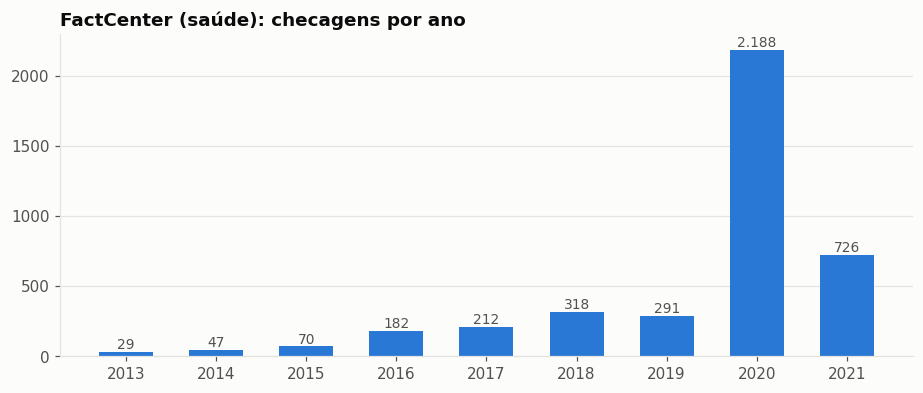

Janela: 2013-07-08 a 2021-05-19 | 54% das checagens são de 2020


In [ ]:
fc["ano"] = pd.to_datetime(fc["publication_date"], errors="coerce").dt.year
por_ano = fc["ano"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(por_ano.index.astype(int).astype(str), por_ano.values, color=AZUL, width=0.6)
ax.grid(axis="x", visible=False)
for x, v in zip(por_ano.index.astype(int).astype(str), por_ano.values):
    ax.text(x, v, f"{v:,}".replace(",", "."), ha="center", va="bottom", color=TINTA2, fontsize=9)
ax.set_title("FactCenter (saúde): checagens por ano")
plt.show()
print(f"Janela: {fc['publication_date'].min()} a {fc['publication_date'].max()} | "
      f"{por_ano.max() / por_ano.sum():.0%} das checagens são de {int(por_ano.idxmax())}")

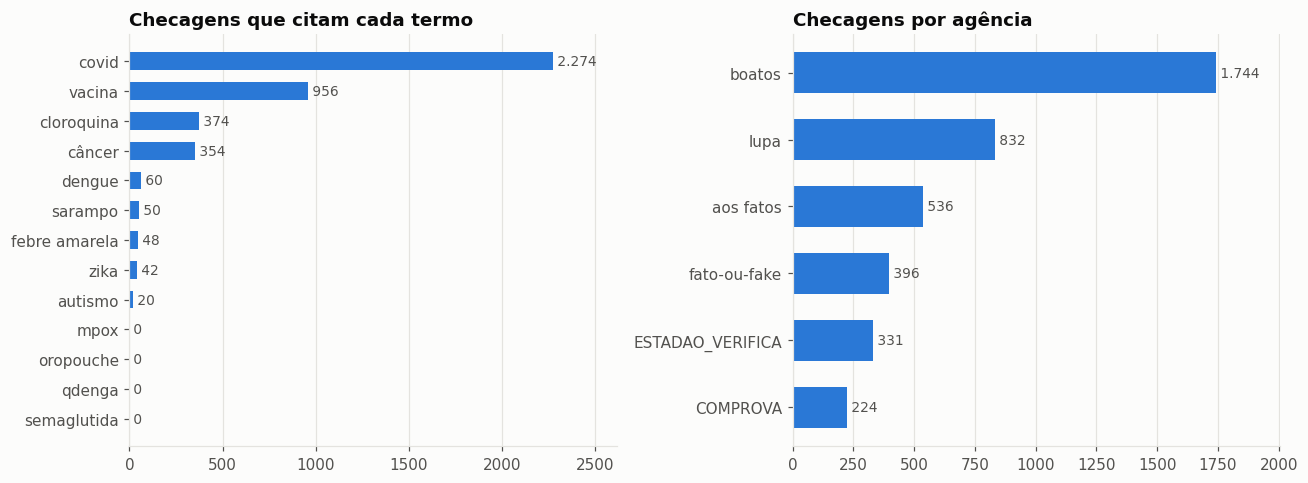

Termos atuais SEM nenhuma checagem: ['mpox', 'oropouche', 'qdenga', 'semaglutida']


In [ ]:
termos = ["covid", "vacina", "cloroquina", "câncer", "dengue", "zika", "febre amarela",
          "sarampo", "autismo", "mpox", "oropouche", "qdenga", "semaglutida"]
texto = (fc["title"].fillna("") + " " + fc["text_news"].fillna("")).str.lower()
contagem = pd.Series({t: int(texto.str.contains(t, regex=False).sum()) for t in termos})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
barras_h(axes[0], contagem, titulo="Checagens que citam cada termo")
barras_h(axes[1], fc["source_name"].value_counts(), cor=AZUL, titulo="Checagens por agência")
plt.tight_layout(); plt.show()
print("Termos atuais SEM nenhuma checagem:", [t for t, v in contagem.items() if v == 0])

**Observações:**
- Mais da metade do corpus é de **2020** (pandemia) e ele **termina em maio de 2021**.
- Temas recentes (mpox, Oropouche, Qdenga, semaglutida) **não aparecem**. Uma mensagem sobre eles não vai achar evidência no RAG. O sistema precisa saber dizer que a pergunta não atende o escopo.
- Uma agência (Boatos.org) domina o corpus, e ela usa o rótulo genérico "boato".

---
## Etapa 4 — Texto: tamanho e integridade

Dois testes simples:
1. **Tamanho do texto por classe:** se a notícia falsa for sempre curta e a real sempre longa, o tamanho vira uma pista indesejada.
2. **Acentos:** contamos letras maiúsculas acentuadas (Á, É, Ç...). Se uma aparece **zero vezes** enquanto a minúscula aparece milhares, o texto provavelmente foi corrompido ou transformado.

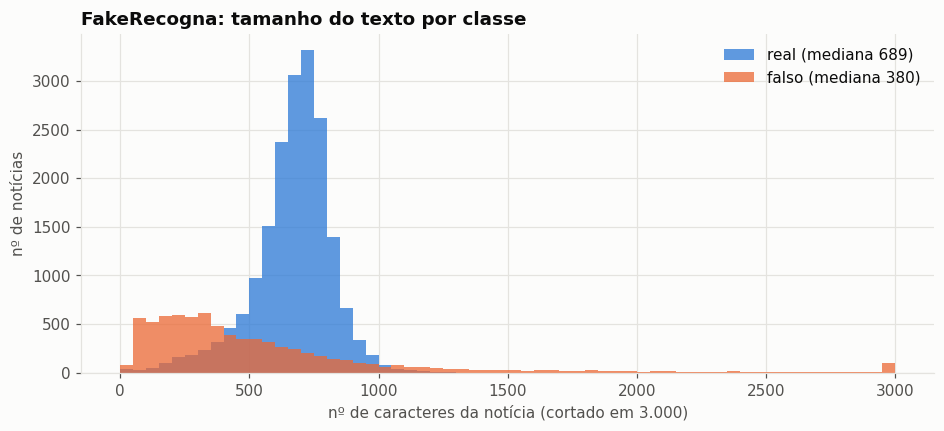

In [10]:
fr["tamanho"] = fr["Noticia"].fillna("").str.len()
real, falso = fr.loc[fr["Label"] == 0, "tamanho"], fr.loc[fr["Label"] == 1, "tamanho"]

fig, ax = plt.subplots(figsize=(10, 4))
bins = range(0, 3001, 50)
ax.hist(real.clip(upper=3000), bins=bins, color=AZUL, alpha=0.75, label=f"real (mediana {real.median():.0f})")
ax.hist(falso.clip(upper=3000), bins=bins, color=LARANJA, alpha=0.75, label=f"falso (mediana {falso.median():.0f})")
ax.set_xlabel("nº de caracteres da notícia (cortado em 3.000)"); ax.set_ylabel("nº de notícias")
ax.set_title("FakeRecogna: tamanho do texto por classe"); ax.legend(frameon=False)
plt.show()

In [11]:
maiusculas = "ÁÀÂÃÉÊÍÓÔÕÚÇ"
def acentos(texto_total):
    return {m: (texto_total.count(m), texto_total.count(m.lower())) for m in maiusculas}

amostras = {
    "FactCenter": " ".join(fc["text_news"].dropna()),
    "FACTCK.BR":  " ".join(ck["reviewBody"].dropna().astype(str)),
    "FakeRecogna": " ".join(fr["Noticia"].dropna().astype(str)),
}
linhas = []
for nome, t in amostras.items():
    for m, (mai, mini) in acentos(t).items():
        linhas.append({"base": nome, "letra": m, "maiúscula": mai, "minúscula": mini})
tab_acentos = pd.DataFrame(linhas)
suspeitas = tab_acentos.query("`maiúscula` == 0 and `minúscula` >= 500")
print("Letras maiúsculas ausentes (com a minúscula frequente) → sinal de texto alterado:")
suspeitas.groupby("base")["letra"].apply("".join).to_frame("letras ausentes")

Letras maiúsculas ausentes (com a minúscula frequente) → sinal de texto alterado:


,letras ausentes
base,
FACTCK.BR,ÁÃÉÍÇ
FakeRecogna,ÁÀÂÃÉÊÍÓÔÕÚÇ


**Observações:**
- No FakeRecogna, a notícia real é bem mais longa que a falsa. Isso implica que a real foi resumida e a falsa não.
- O FACTCK.BR **perdeu maiúsculas acentuadas** (bug na fonte). O FakeRecogna tem o texto transformado (sem caixa alta). Por isso as duas bases estão **reprovadas para citação ao usuário**. O FactCenter passa no teste.

---
## Etapa 5 — Vazamento
Vazamento é quando uma característica irrelevante (tamanho, fonte, formatação) entrega o rótulo sozinha.
Teste simples: pegamos uma amostra **balanceada** (mesmo número de reais e falsas) e perguntamos:
*"se eu chutar 'real' sempre que o texto passar de X caracteres, quanto eu acerto?"*

- Chute aleatório numa base balanceada acerta ~**50%**.
- Se o tamanho sozinho acertar muito mais que isso, a base não serve para medir se alguém sabe discernir, porque dá para acertar sem ler.

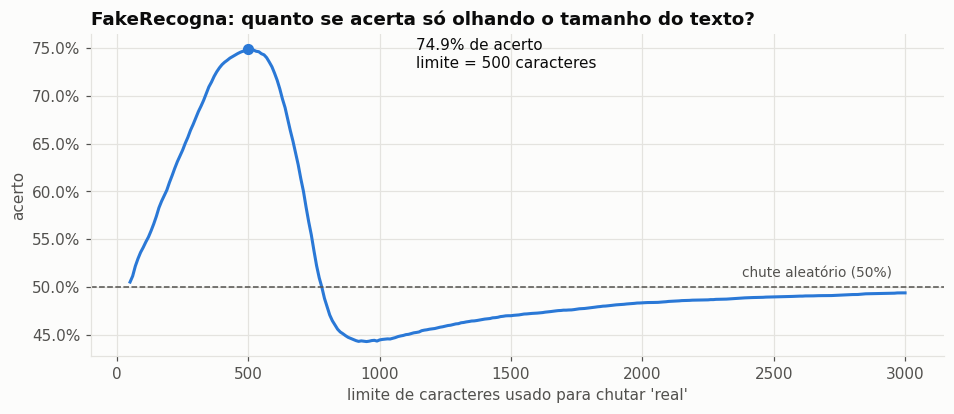

Amostra balanceada de 15,304 notícias. Melhor regra: 'real se tiver mais de 500 caracteres' → 74.9% de acerto.


In [12]:
n = min((fr["Label"] == 0).sum(), (fr["Label"] == 1).sum())
bal = pd.concat([fr[fr["Label"] == 0].sample(n, random_state=42),
                 fr[fr["Label"] == 1].sample(n, random_state=42)])

limites = range(50, 3001, 10)
acertos = pd.Series({L: ((bal["tamanho"] > L).astype(int) == (bal["Label"] == 0)).mean() for L in limites})
melhor = acertos.idxmax()

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(acertos.index, acertos.values, color=AZUL, linewidth=2)
ax.axhline(0.5, color=TINTA2, linestyle="--", linewidth=1)
ax.text(2950, 0.51, "chute aleatório (50%)", ha="right", color=TINTA2, fontsize=9)
ax.scatter([melhor], [acertos.max()], color=AZUL, s=40, zorder=3)
ax.annotate(f"{acertos.max():.1%} de acerto\nlimite = {melhor} caracteres", (melhor, acertos.max()),
            xytext=(110, -12), textcoords="offset points", color=TINTA)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("limite de caracteres usado para chutar 'real'"); ax.set_ylabel("acerto")
ax.set_title("FakeRecogna: quanto se acerta só olhando o tamanho do texto?")
plt.show()
print(f"Amostra balanceada de {2*n:,} notícias. Melhor regra: 'real se tiver mais de {melhor} caracteres' → {acertos.max():.1%} de acerto.")

**Observações:** uma regra de uma linha ("real se tiver mais de ~500 caracteres") acerta **cerca de 75%**, sem ler nada. (Com um classificador um pouco mais esperto, o tratamento do projeto chegou a 80,5%.)
Isso confirma o que o projeto já decidiu: o FakeRecogna é **banco de estímulos, nunca base de treino de veredito**.
E os itens reais precisam ser **revisados/reescritos** antes do teste com usuários, senão a pessoa acerta pelo tamanho e não pelo critério.

---
## Resumo: o que a análise mostrou

| # | Achado | Impacto no projeto |
|---|---|---|
| 1 | FactCenter tem texto íntegro e completo | É o **corpus confiável** para o RAG |
| 2 | Quase nenhum item "verdadeiro" em português | Itens verdadeiros contraintuitivos precisam de **coleta manual** (Fiocruz, MS etc.) |
| 3 | 26 grafias para poucos vereditos | Sempre usar o `rotulo_consolidado`, nunca o `rating` bruto |
| 4 | Corpus termina em 2021; temas recentes com zero checagens | O copiloto precisa **reconhecer quando não tem evidência** |
| 5 | FACTCK.BR e FakeRecogna com texto corrompido/transformado | **Não citar** trechos dessas bases ao usuário |
| 6 | Tamanho do texto entrega o rótulo no FakeRecogna | Revisar os estímulos antes do teste com usuário |
| 7 | FakeHealth equilibrado e InSciOut com força da afirmação | Boa base para **ensinar critérios** (Matriz de Confiança, "a manchete exagera?") |

**Oportunidades para as próximas etapas:** os casos de empate entre médicos do WhaVax (84) servem de casos difíceis para avaliação. As explicações dos especialistas no FakeHealth ajudam a redigir o critério que o usuário vai aprender. E a contagem de termos (Etapa 3) pode ser refeita periodicamente para monitorar lacunas de cobertura.